# Análisis Sistémico de la Cadena de Suministro: Simulación Beer Game
Este Jupyter Notebook contiene el análisis cuantitativo y cualitativo de la simulación "Beer Game" realizada para la materia de Perspectiva Sistémica. El objetivo principal es identificar y describir los niveles de explicación de una problemática compleja (el Efecto Látigo) a través del procesamiento de datos generados durante 20 semanas de operación en el rol de Distribuidor.

El análisis se centra en cómo los retrasos de tiempo (time delays) y la falta de visibilidad de la demanda real impactan en los costos operativos y en la estabilidad del inventario.

✅ Datos cargados desde: ../data/data_beer_game.csv
--------------------------------------------------
ESTADÍSTICAS FINALES (Semana 21)
--------------------------------------------------
Varianza de Pedidos: 5.97 (Indicador de Látigo)
Costo por Inventario: $86.00
Costo por Backlog:    $34.00
Costo Total:          $1800.00
--------------------------------------------------


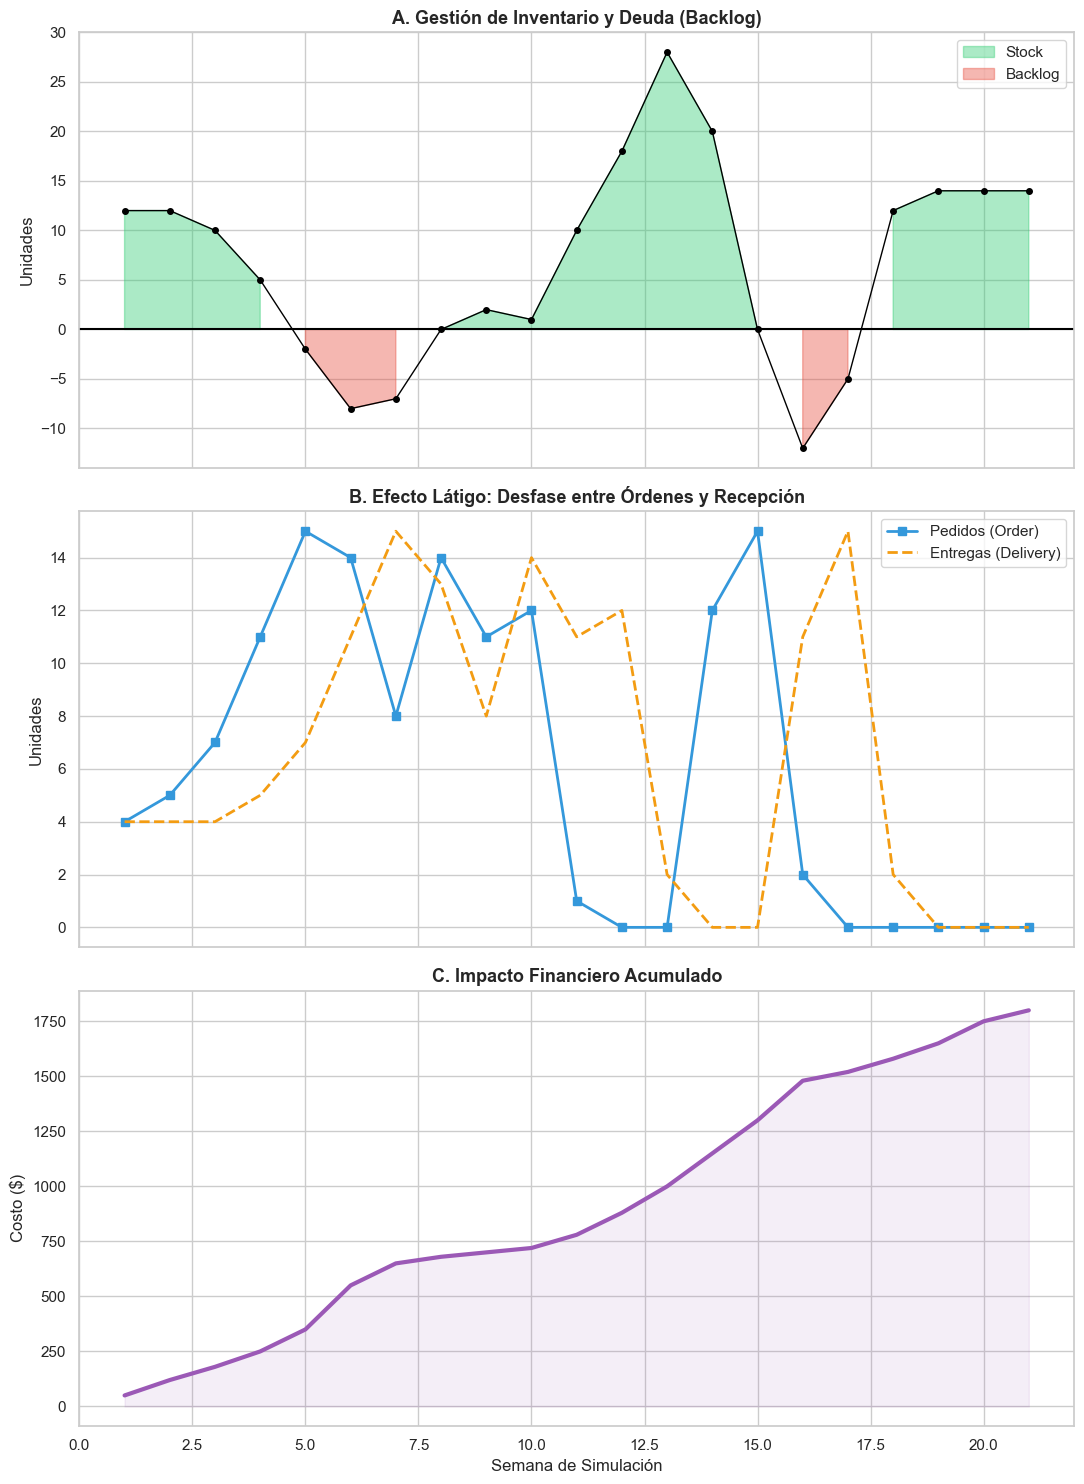

In [8]:
import os

def analizar_simulacion_beer_game(ruta_csv):
    """
    Analiza y visualiza los resultados del Beer Game.
    Calcula costos de Inventario ($0.50) y Backlog ($1.00).
    """

    # 1. IMPORTACIÓN Y VALIDACIÓN DE DATOS
    if os.path.exists(ruta_csv):
        df = pd.read_csv(ruta_csv)
        print(f"✅ Datos cargados desde: {ruta_csv}")
    else:
        print(f"⚠️ Ruta no encontrada. Usando datos de respaldo...")
        data = {
            'Semana': range(1, 22),
            'Stock': [12, 12, 10, 5, -2, -8, -7, 0, 2, 1, 10, 18, 28, 20, 0, -12, -5, 12, 14, 14, 14],
            'Order (Pedidos)': [4, 5, 7, 11, 15, 14, 8, 14, 11, 12, 1, 0, 0, 12, 15, 2, 0, 0, 0, 0, 0],
            'Incoming Delivery (Entregas)': [4, 4, 4, 5, 7, 11, 15, 13, 8, 14, 11, 12, 2, 0, 0, 11, 15, 2, 0, 0, 0],
            'Costo Acumulado': [50, 120, 180, 250, 350, 550, 650, 680, 700, 720, 780, 880, 1000, 1150, 1300, 1480, 1520, 1580, 1650, 1750, 1800]
        }
        df = pd.DataFrame(data)

    # 2. CÁLCULOS SISTÉMICOS Y FINANCIEROS
    # El Backlog se identifica como valores negativos en la columna 'Stock'
    # Costo Holding = $0.50 | Costo Backlog = $1.00 (Penalización por deuda)
    df['Costo_Inv_Semanal'] = df['Stock'].apply(lambda x: x * 0.50 if x > 0 else 0)
    df['Costo_Backlog_Semanal'] = df['Stock'].apply(lambda x: abs(x) * 1.00 if x < 0 else 0)

    std_order = df['Order (Pedidos)'].std()
    total_inv = df['Costo_Inv_Semanal'].sum()
    total_backlog = df['Costo_Backlog_Semanal'].sum()

    # 3. CONFIGURACIÓN VISUAL (3 Subplots)
    sns.set_theme(style="whitegrid")
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(11, 15), sharex=True)

    # --- PANEL A: INVENTARIO VS BACKLOG ---
    # Lógica: El Backlog es la 'deuda' acumulada cuando el stock es insuficiente.
    ax1.fill_between(df['Semana'], df['Stock'], 0, where=(df['Stock'] >= 0), color='#2ecc71', alpha=0.4, label='Stock')
    ax1.fill_between(df['Semana'], df['Stock'], 0, where=(df['Stock'] < 0), color='#e74c3c', alpha=0.4, label='Backlog')
    ax1.plot(df['Semana'], df['Stock'], color='black', marker='o', markersize=4, linewidth=1)
    ax1.axhline(0, color='black', lw=1.5)
    ax1.set_title('A. Gestión de Inventario y Deuda (Backlog)', fontsize=13, fontweight='bold')
    ax1.set_ylabel('Unidades')
    ax1.legend(loc='upper right')

    # --- PANEL B: EL EFECTO LÁTIGO (TIME DELAYS) ---
    # Lógica: Comparar pedidos vs entregas revela el retraso estructural del sistema.
    ax2.plot(df['Semana'], df['Order (Pedidos)'], label='Pedidos (Order)', color='#3498db', lw=2, marker='s')
    ax2.plot(df['Semana'], df['Incoming Delivery (Entregas)'], label='Entregas (Delivery)', color='#f39c12', lw=2, ls='--')
    ax2.set_title('B. Efecto Látigo: Desfase entre Órdenes y Recepción', fontsize=13, fontweight='bold')
    ax2.set_ylabel('Unidades')
    ax2.legend(loc='upper right')

    # --- PANEL C: COSTOS ACUMULADOS ---
    # Lógica: Visualiza la pendiente del costo; a mayor inestabilidad, mayor pendiente.
    ax3.plot(df['Semana'], df['Costo Acumulado'], color='#9b59b6', lw=3, label='Costo Total')
    ax3.fill_between(df['Semana'], df['Costo Acumulado'], color='#9b59b6', alpha=0.1)
    ax3.set_title('C. Impacto Financiero Acumulado', fontsize=13, fontweight='bold')
    ax3.set_ylabel('Costo ($)')
    ax3.set_xlabel('Semana de Simulación')

    # 4. REPORTE EN CONSOLA
    print("-" * 50)
    print(f"ESTADÍSTICAS FINALES (Semana {df['Semana'].max()})")
    print("-" * 50)
    print(f"Varianza de Pedidos: {std_order:.2f} (Indicador de Látigo)")
    print(f"Costo por Inventario: ${total_inv:.2f}")
    print(f"Costo por Backlog:    ${total_backlog:.2f}")
    print(f"Costo Total:          ${df['Costo Acumulado'].max():.2f}")
    print("-" * 50)

    plt.tight_layout()
    plt.show()
    return df

# EJECUCIÓN DEL SCRIPT
df_final = analizar_simulacion_beer_game('../data/data_beer_game.csv')

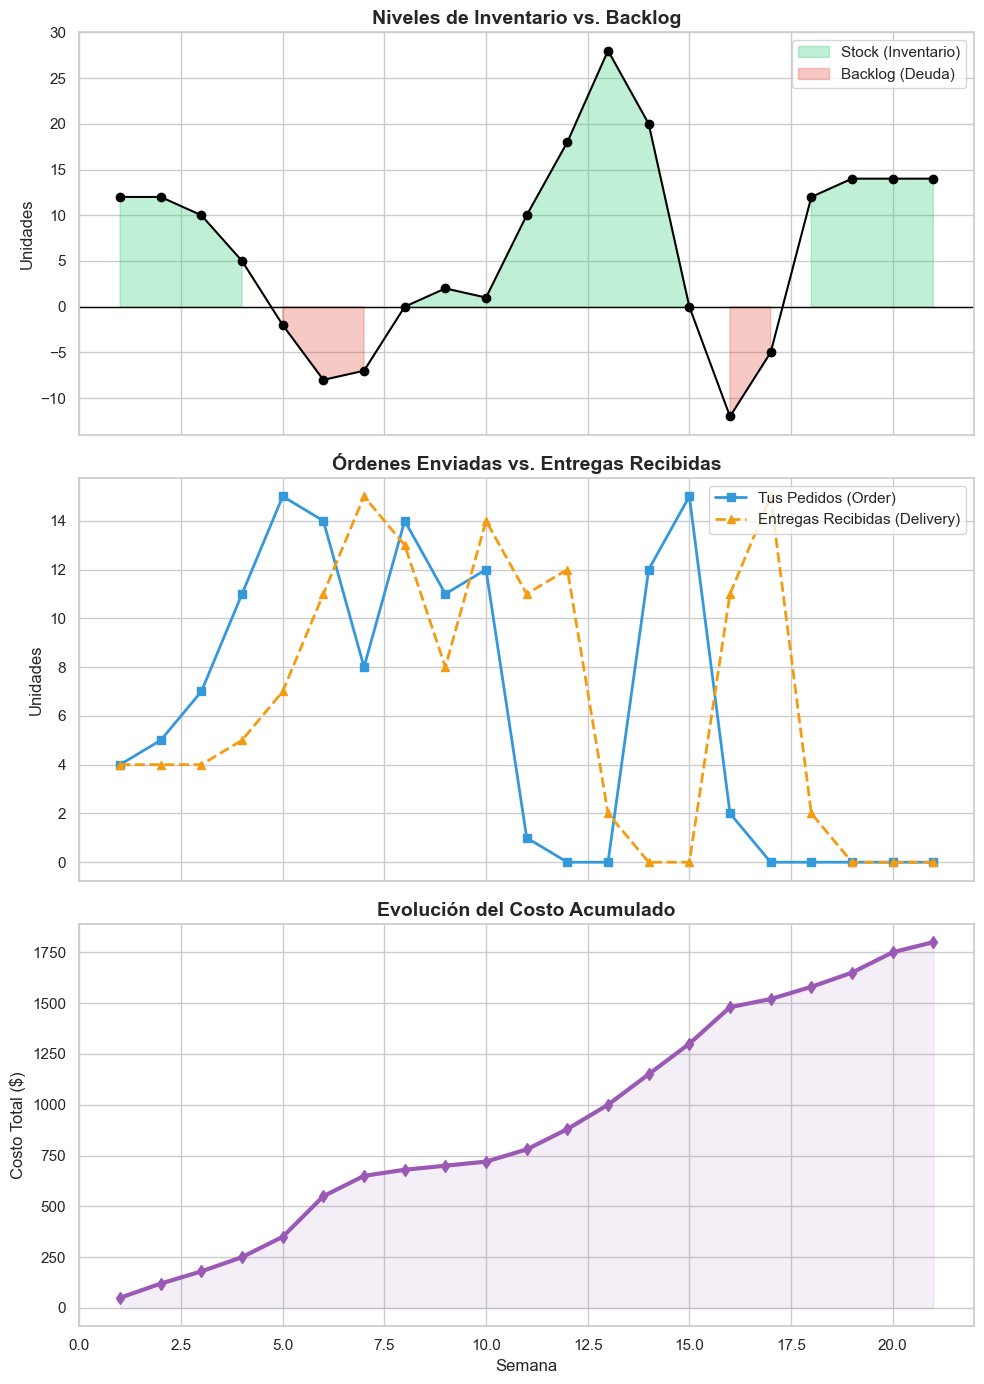

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def generar_reporte_grafico(ruta_csv):
    # 1. Cargar los datos
    try:
        df = pd.read_csv(ruta_csv)
    except:
        print("Archivo no encontrado. Asegúrate de que la ruta es correcta.")
        return

    # Configuración de estilo profesional
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(3, 1, figsize=(10, 14), sharex=True)

    # --- GRÁFICA 1: STOCK Y BACKLOG ---
    # Área verde para inventario positivo, roja para deuda (backlog)
    axes[0].fill_between(df['Semana'], df['Stock'], 0, where=(df['Stock'] >= 0),
                         color='#2ecc71', alpha=0.3, label='Stock (Inventario)')
    axes[0].fill_between(df['Semana'], df['Stock'], 0, where=(df['Stock'] < 0),
                         color='#e74c3c', alpha=0.3, label='Backlog (Deuda)')
    axes[0].plot(df['Semana'], df['Stock'], color='black', marker='o', linewidth=1.5)
    axes[0].axhline(0, color='black', linewidth=1)
    axes[0].set_title('Niveles de Inventario vs. Backlog', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Unidades')
    axes[0].legend(loc='upper right')

    # --- GRÁFICA 2: ÓRDENES VS ENTREGAS (EL LÁTIGO) ---
    axes[1].plot(df['Semana'], df['Order (Pedidos)'], label='Tus Pedidos (Order)',
                 color='#3498db', marker='s', linewidth=2)
    axes[1].plot(df['Semana'], df['Incoming Delivery (Entregas)'], label='Entregas Recibidas (Delivery)',
                 color='#f39c12', linestyle='--', marker='^', linewidth=2)
    axes[1].set_title('Órdenes Enviadas vs. Entregas Recibidas', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Unidades')
    axes[1].legend(loc='upper right')

    # --- GRÁFICA 3: COSTOS ACUMULADOS ---
    axes[2].plot(df['Semana'], df['Costo Acumulado'], color='#9b59b6', linewidth=3, marker='d')
    axes[2].fill_between(df['Semana'], df['Costo Acumulado'], color='#9b59b6', alpha=0.1)
    axes[2].set_title('Evolución del Costo Acumulado', fontsize=14, fontweight='bold')
    axes[2].set_ylabel('Costo Total ($)')
    axes[2].set_xlabel('Semana')

    plt.tight_layout()
    plt.savefig('grafica_final_beergame.png', dpi=300) # Guarda la imagen en alta calidad
    plt.show()

# Ejecución (ajusta la ruta a tu archivo)
generar_reporte_grafico('../data/data_beer_game.csv')